In [1]:
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from src.callback import TrainingCallback, env_callback

In [2]:
env = env_callback()
n_actions = env.action_space.shape[-1]
vec_env = make_vec_env(env_callback, n_envs=8)

model = SAC(
    "MlpPolicy",
    vec_env,
    verbose=0,
    tensorboard_log="results",
)

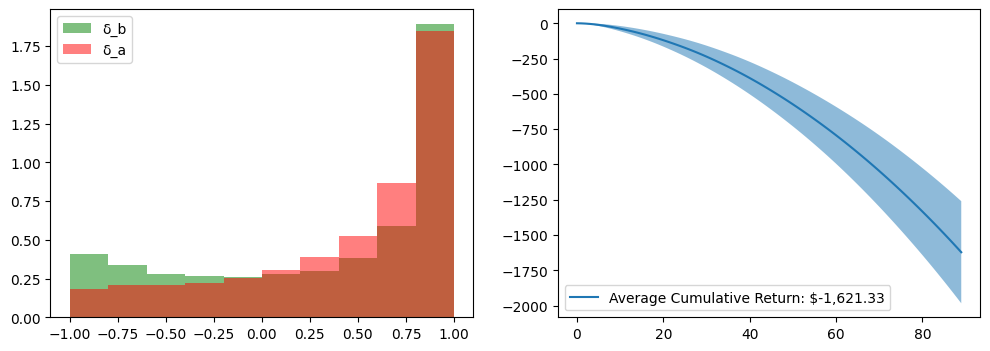

In [3]:
# to load already trained model
# model = SAC.load("models/SAC_32000_steps")

model.env = vec_env

model.learn(
    total_timesteps=100000,
    callback=[
        TrainingCallback(1000, env_callback()),
        CheckpointCallback(1000, "models", name_prefix="SAC"),
    ],
)